<a href="https://www.kaggle.com/code/jayhawk1900/irrigation-need-stacking-hybrid?scriptVersionId=312616617" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Step 5 v2: Hybrid Stacking — Option B Experiment
**Playground Series S6E4 — Irrigation Need Prediction**  
**v1 Result:** LB 0.97015 | OOF 0.97140 | Rank 615/2125  
**v2 Change:** Removed `class_weight='balanced'` from LogReg stacker — testing whether threshold optimization can reclaim more bps  
**v2 Result:**

## Overview

This notebook implements a **stacked ensemble** of 4 diverse base models whose predictions are combined by a logistic regression meta-learner, followed by threshold optimization.

**v2 Hypothesis:** In v1, threshold optimization added only +3.2 bps vs ~20 bps typical for weighted ensembles. We hypothesized the LogReg stacker's `class_weight='balanced'` was already rebalancing probabilities for balanced accuracy, leaving no headroom for thresholds. **v2 removes that parameter** — the stacker should produce raw probabilities, and thresholds should reclaim their typical +15-20 bps gain.

### Architecture

| Layer | Component | v1 OOF BA |
|-------|-----------|-----------|
| Features | 97 engineered + 24 OOF target-encoded = **121 features** | — |
| Base 1 | LightGBM (5-fold, balanced class weights) | 0.9628 |
| Base 2 | XGBoost (5-fold, GPU, balanced sample weights) | 0.9692 |
| Base 3 | CatBoost (5-fold, native categorical handling) | 0.9686 |
| Base 4 | ExtraTrees (5-fold, bagging for diversity) | 0.9568 |
| Stacker | Logistic Regression on 12 OOF probability columns | 0.9711 |
| Post-proc | Threshold optimization (High × 1.32, Medium × 0.82) | **0.9714** |

### Key Design Decisions

- **Shared fold splits** across all 4 base models for clean OOF alignment for the stacker
- **Out-of-fold target encoding** computed inside the fold loop — zero leakage
- **ExtraTrees for diversity** — its bagging-based errors are structurally different from the 3 GBMs (correlation 0.89 vs GBM pairwise 0.96-0.99)
- **v2 change:** LogReg stacker no longer uses `class_weight='balanced'` — threshold optimization now does the full rebalancing work

### Pipeline

1. Data loading + cleaning
2. Advanced feature engineering (tier 1 interactions, tier 2 group aggregations, tier 3 frequency + ratios)
3. Out-of-fold target encoding (8 cats × 3 classes = 24 new columns)
4. Base models: LightGBM → XGBoost → CatBoost → ExtraTrees
5. Diversity check on High-class probability correlations
6. Logistic regression stacker with nested 5-fold CV *(v2: no class_weight)*
7. Threshold optimization (coarse + fine grid)
8. Submission

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
# ============================================================
# STEP 1: Setup, imports, and data loading (consolidated)
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

SEED = 42
N_FOLDS = 5
print(f'Seed: {SEED} | Folds: {N_FOLDS}')

# ---- Load competition CSVs (no original dataset) ----
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

# ---- Fix dtype contamination ----
for c in ['Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']:
    train[c] = pd.to_numeric(train[c], errors='coerce')

# ---- Drop corrupted rows ----
bad_mask = train['Soil_Type'].str.match(r'^\d', na=False)
train = train[~bad_mask].reset_index(drop=True)

# ---- Separate IDs ----
test_ids = test['id'].copy()
train = train.drop(columns='id')
test  = test.drop(columns='id')

# ---- Drop any rows with missing target ----
train = train.dropna(subset=['Irrigation_Need']).reset_index(drop=True)

# ---- Split features from target ----
TARGET = 'Irrigation_Need'
y_train = train[TARGET].copy()
X_train = train.drop(columns=TARGET)
X_test  = test.copy()

# ---- Identify column types ----
NUM_COLS = X_train.select_dtypes(include='number').columns.tolist()
CAT_COLS = X_train.select_dtypes(include='object').columns.tolist()

# ---- Encode target ----
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y_train)
class_names = le_target.classes_

# ---- Sanity check ----
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Classes: {list(class_names)} -> {list(range(len(class_names)))}')
print(f'Categorical cols ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Numeric cols ({len(NUM_COLS)}): {NUM_COLS}')

class_dist = pd.Series(y_encoded).map(dict(enumerate(class_names))).value_counts(normalize=True).round(4)
print(f'\nClass distribution:\n{class_dist}')

Seed: 42 | Folds: 5
X_train: (630000, 19) | X_test: (270000, 19)
Classes: ['High', 'Low', 'Medium'] -> [0, 1, 2]
Categorical cols (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numeric cols (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Class distribution:
Low       0.5872
Medium    0.3795
High      0.0333
Name: proportion, dtype: float64


In [3]:
# ============================================================
# STEP 2: Advanced Feature Engineering (97 features)
# ============================================================
# Three tiers of engineered features, identical to Step 4's winning FE pipeline:
#   Tier 1: Domain interactions (physics of irrigation)
#   Tier 2: Group aggregations (mean/std/diff per category)
#   Tier 3: Frequency encoding + ratios
# Produces two frames: one label-encoded (for LGB/XGB/ET), one with raw
# strings (for CatBoost's native categorical handling).

# ---- Tier 1: Domain Interactions ----
# Physics-motivated features — encode irrigation engineering intuition.
def add_tier1_interactions(df):
    df = df.copy()
    # Evapotranspiration proxy: warm + sunny + dry = high water loss
    df['ET_index'] = df['Temperature_C'] * df['Sunlight_Hours'] / (df['Humidity'] + 1)
    # Total water available to crop
    df['water_supply'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    # Drought index: penalties for low rain AND low soil moisture
    df['drought_index'] = (
        np.maximum(0, 800 - df['Rainfall_mm'])
        + np.maximum(0, 40 - df['Soil_Moisture']) * 10
    ) / (df['Humidity'] + 1)
    # Ratio of demand to supply
    df['water_stress'] = df['ET_index'] / (df['water_supply'] + 1)
    df['moist_x_temp'] = df['Soil_Moisture'] * df['Temperature_C']
    df['rain_per_area'] = df['Rainfall_mm'] / (df['Field_Area_hectare'] + 0.1)
    return df

X_train = add_tier1_interactions(X_train)
X_test  = add_tier1_interactions(X_test)

# ---- Tier 2: Group Aggregations ----
# For each (categorical, numeric) pair, compute mean + std + diff_from_mean.
# Maps are built on TRAIN only, then broadcast to test (prevents leakage).
# NaN in test (for unseen categories) filled with global train statistics.
agg_nums = ['Soil_Moisture', 'Rainfall_mm', 'Temperature_C', 'Wind_Speed_kmh', 'Humidity']
agg_cats = ['Crop_Growth_Stage', 'Crop_Type', 'Region', 'Season']

for cat in agg_cats:
    for num in agg_nums:
        grp = X_train.groupby(cat)[num]
        mean_map = grp.mean()
        std_map  = grp.std().fillna(0)

        mean_col = f'{num}_mean_by_{cat}'
        std_col  = f'{num}_std_by_{cat}'
        diff_col = f'{num}_diff_from_{cat}_mean'  # often the strongest signal

        X_train[mean_col] = X_train[cat].map(mean_map)
        X_test[mean_col]  = X_test[cat].map(mean_map).fillna(X_train[num].mean())

        X_train[std_col] = X_train[cat].map(std_map)
        X_test[std_col]  = X_test[cat].map(std_map).fillna(X_train[num].std())

        X_train[diff_col] = X_train[num] - X_train[mean_col]
        X_test[diff_col]  = X_test[num] - X_test[mean_col]

# ---- Tier 3: Frequency Encoding ----
# For each categorical, the proportion of rows with that value.
# Captures how common/rare each category is (a class-prior signal).
for col in CAT_COLS:
    freq_col = f'{col}_freq'
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[freq_col] = X_train[col].map(freq_map)
    X_test[freq_col]  = X_test[col].map(freq_map).fillna(0)

# ---- Tier 3: Handcrafted Ratios ----
# Cheap features that help trees skip having to re-discover these combinations.
X_train['moisture_humidity_ratio'] = X_train['Soil_Moisture'] / (X_train['Humidity'] + 1)
X_test['moisture_humidity_ratio']  = X_test['Soil_Moisture'] / (X_test['Humidity'] + 1)

X_train['temp_wind_product'] = X_train['Temperature_C'] * X_train['Wind_Speed_kmh']
X_test['temp_wind_product']  = X_test['Temperature_C'] * X_test['Wind_Speed_kmh']

# Rain deficit relative to median rainfall (negative = wetter than normal)
rain_median = X_train['Rainfall_mm'].median()
X_train['rain_deficit'] = rain_median - X_train['Rainfall_mm']
X_test['rain_deficit']  = rain_median - X_test['Rainfall_mm']

X_train['soil_conductivity_ratio'] = X_train['Soil_Moisture'] / (X_train['Electrical_Conductivity'] + 0.1)
X_test['soil_conductivity_ratio']  = X_test['Soil_Moisture'] / (X_test['Electrical_Conductivity'] + 0.1)

# ---- Save a RAW copy for CatBoost BEFORE label encoding ----
# CatBoost uses its own ordered target statistics on raw string categoricals —
# pre-encoding would hurt its performance.
X_train_cat = X_train.copy()
X_test_cat  = X_test.copy()
cat_feature_names = CAT_COLS.copy()  # used later as CatBoost's cat_features arg

# ---- Label-encode categoricals for XGB / LGB / ExtraTrees ----
# Fit on concatenated train+test to ensure no unseen labels at inference.
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([X_train[col], X_test[col]], axis=0).astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    # Ensure CatBoost copy's categoricals are strings (CatBoost requirement)
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col]  = X_test_cat[col].astype(str)
    le_dict[col] = le

# ---- Sanity checks ----
print(f'Total features after FE: {X_train.shape[1]}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'X_train_cat: {X_train_cat.shape} | X_test_cat: {X_test_cat.shape}')
print(f'Any NaN — train: {X_train.isna().any().any()} | test: {X_test.isna().any().any()}')
print(f'Any NaN — train_cat: {X_train_cat.isna().any().any()} | test_cat: {X_test_cat.isna().any().any()}')
print(f'CatBoost categorical features: {cat_feature_names}')

Total features after FE: 97
X_train: (630000, 97) | X_test: (270000, 97)
X_train_cat: (630000, 97) | X_test_cat: (270000, 97)
Any NaN — train: False | test: False
Any NaN — train_cat: False | test_cat: False
CatBoost categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [4]:
# ============================================================
# STEP 3: OOF Target Encoding (NEW — not in Step 4)
# ============================================================
# For each categorical × each class, compute P(class | category) — smoothed
# and computed out-of-fold so no row sees an encoding derived from its own label.
#
# Why: frequency encoding captures HOW COMMON a category is; target encoding
# captures HOW PREDICTIVE it is. Different signal. Usually worth 3-8 bps.
#
# Adds: 8 categoricals × 3 classes = 24 new features. Total: 97 → 121.

# ---- Cache fold splits ----
# Every base model AND the stacker will use THESE EXACT splits.
# This is what makes the stacker's OOF predictions consistent and aligned.
skf_master = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_splits = list(skf_master.split(X_train, y_encoded))
print(f'Cached {len(fold_splits)} fold splits — shared across all base models')

# ---- Global prior: fallback for unseen categories in test ----
# For each class, its overall frequency in the training data.
SMOOTHING = 20.0
global_prior = np.array([(y_encoded == c).mean() for c in range(3)])
print(f'Global prior [High, Low, Medium]: {global_prior.round(4)}')
print(f'Smoothing alpha: {SMOOTHING}')

# ---- Pre-allocate TE arrays ----
# te_train: row i gets encoding computed from its VALIDATION fold only
# te_test_folds: one test encoding per fold; we'll average them at the end
te_train = np.zeros((len(X_train), len(CAT_COLS) * 3))
te_test_folds = np.zeros((N_FOLDS, len(X_test), len(CAT_COLS) * 3))

# ---- OOF loop: for each fold, build encoding maps on TRAINING rows only ----
for fold_idx, (trn_idx, val_idx) in enumerate(fold_splits):
    for ci, col in enumerate(CAT_COLS):
        trn_col = X_train.iloc[trn_idx][col].values
        val_col = X_train.iloc[val_idx][col].values
        test_col = X_test[col].values
        trn_y = y_encoded[trn_idx]

        # One encoding column per class — captures the full multi-class signal
        for cls in range(3):
            # Binary target for this class: 1 if row == cls, else 0
            y_bin = (trn_y == cls).astype(float)
            df_tmp = pd.DataFrame({'cat': trn_col, 'y': y_bin})
            stats = df_tmp.groupby('cat')['y'].agg(['mean', 'count'])

            # Smoothed encoding: blend group mean toward global prior
            # Rare categories (small count) get pulled toward the prior
            smoothed = (stats['mean'] * stats['count'] + global_prior[cls] * SMOOTHING) / \
                       (stats['count'] + SMOOTHING)
            enc_map = smoothed.to_dict()

            out_col = ci * 3 + cls

            # Apply map to validation rows (the OOF predictions for this fold)
            te_train[val_idx, out_col] = (
                pd.Series(val_col).map(enc_map).fillna(global_prior[cls]).values
            )
            # Apply same map to test rows (one version per fold)
            te_test_folds[fold_idx, :, out_col] = (
                pd.Series(test_col).map(enc_map).fillna(global_prior[cls]).values
            )

# ---- Test encoding = average across fold-wise encodings ----
# Standard OOF-TE pattern — each fold's map saw different training rows, so
# averaging gives a more stable encoding than any single fold's map.
te_test = te_test_folds.mean(axis=0)

# ---- Convert to DataFrames with sensible column names ----
te_col_names = [f'te_{col}_cls{cls}' for col in CAT_COLS for cls in range(3)]
te_train_df = pd.DataFrame(te_train, columns=te_col_names, index=X_train.index)
te_test_df  = pd.DataFrame(te_test,  columns=te_col_names, index=X_test.index)

# ---- Append to both frames (label-encoded and CatBoost-raw) ----
X_train = pd.concat([X_train, te_train_df], axis=1)
X_test  = pd.concat([X_test,  te_test_df],  axis=1)
X_train_cat = pd.concat([X_train_cat, te_train_df], axis=1)
X_test_cat  = pd.concat([X_test_cat,  te_test_df],  axis=1)

# ---- Sanity checks ----
print(f'\nTotal features after TE: {X_train.shape[1]} (expected 121)')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Any NaN — train: {X_train.isna().any().any()} | test: {X_test.isna().any().any()}')
print(f'\nSample TE columns (first row, first 2 cats x 3 classes):')
print(X_train[te_col_names[:6]].iloc[0].round(4))
print(f'\nTE column value ranges (should all be between 0 and 1):')
print(f'  min: {X_train[te_col_names].values.min():.4f}')
print(f'  max: {X_train[te_col_names].values.max():.4f}')

Cached 5 fold splits — shared across all base models
Global prior [High, Low, Medium]: [0.0333 0.5872 0.3795]
Smoothing alpha: 20.0

Total features after TE: 121 (expected 121)
X_train: (630000, 121) | X_test: (270000, 121)
Any NaN — train: False | test: False

Sample TE columns (first row, first 2 cats x 3 classes):
te_Soil_Type_cls0    0.0289
te_Soil_Type_cls1    0.5986
te_Soil_Type_cls2    0.3725
te_Crop_Type_cls0    0.0390
te_Crop_Type_cls1    0.5936
te_Crop_Type_cls2    0.3674
Name: 0, dtype: float64

TE column value ranges (should all be between 0 and 1):
  min: 0.0015
  max: 0.8728


In [5]:
# ============================================================
# STEP 4: Base Model 1 — LightGBM (5-fold CV)
# ============================================================
# Hyperparameters identical to Step 4 — we're not re-tuning so any lift over
# 0.9669 LGB baseline comes from the new target encoding features.
# Uses the cached fold_splits from Step 3 — identical splits across all 4 base models.

# ---- LightGBM hyperparameters (frozen from Step 4) ----
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'class_weight': 'balanced',   # weights inversely to class freq (High gets ~18x Low)
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

# ---- OOF containers ----
oof_lgb = np.zeros((len(X_train), 3))   # 1 row per training sample, 3 class probs
test_lgb = np.zeros((len(X_test), 3))   # averaged across folds
lgb_fold_scores = []

# ---- 5-fold loop using cached splits from Step 3 ----
for fold, (trn_idx, val_idx) in enumerate(fold_splits, 1):
    X_trn, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_trn, y_val = y_encoded[trn_idx], y_encoded[val_idx]

    dtrain = lgb.Dataset(X_trn, label=y_trn)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    # OOF: predict on this fold's validation rows — the stacker's input later
    oof_lgb[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    # Test predictions: average across all 5 fold models
    test_lgb += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, oof_lgb[val_idx].argmax(axis=1))
    lgb_fold_scores.append(fold_ba)
    print(f'  Fold {fold}: BA = {fold_ba:.6f}  (best_iter = {model.best_iteration})')

# ---- Final OOF score ----
lgb_ba = balanced_accuracy_score(y_encoded, oof_lgb.argmax(axis=1))
print(f'\n{"="*60}')
print(f'  LightGBM — OOF BA: {lgb_ba:.6f}')
print(f'  Mean Fold BA: {np.mean(lgb_fold_scores):.6f} ± {np.std(lgb_fold_scores):.6f}')
print(f'  Step 4 baseline: 0.966911 — delta: {(lgb_ba - 0.966911)*10000:+.1f} bps')
print(f'{"="*60}')

# ---- Save OOF + test predictions (stacker input later; also protects against session timeout) ----
np.save('/kaggle/working/oof_lgb.npy', oof_lgb)
np.save('/kaggle/working/test_lgb.npy', test_lgb)
print('\nSaved: oof_lgb.npy, test_lgb.npy')

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[271]	valid_0's multi_logloss: 0.0574149
  Fold 1: BA = 0.961619  (best_iter = 271)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[274]	valid_0's multi_logloss: 0.0583337
  Fold 2: BA = 0.963453  (best_iter = 274)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[269]	valid_0's multi_logloss: 0.058415
  Fold 3: BA = 0.964119  (best_iter = 269)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[253]	valid_0's multi_logloss: 0.057255
  Fold 4: BA = 0.962597  (best_iter = 253)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[235]	valid_0's multi_logloss: 0.0565556
  Fold 5: BA = 0.962433  (best_iter = 235)

  LightGBM — OOF BA: 0.962844
  Mean Fold BA: 0.962844 ± 0.000864
  Step 4 baseline: 0.966911 — 

In [6]:
# ============================================================
# STEP 5: Base Model 2 — XGBoost (5-fold CV, GPU)
# ============================================================
# Same 121 features, same fold_splits, different algorithm.
# XGB's depth-wise trees + exact split-finding produce different errors than
# LGB's leaf-wise trees — that's the diversity the stacker exploits later.

# ---- XGBoost hyperparameters (frozen from Step 4) ----
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 50,          # XGB equivalent of min_samples_leaf
    'tree_method': 'hist',
    'device': 'cuda',                 # GPU — much faster than CPU exact
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': 0,
}

# ---- OOF containers (shape matches LGB for eventual stacker concat) ----
oof_xgb = np.zeros((len(X_train), 3))
test_xgb = np.zeros((len(X_test), 3))
xgb_fold_scores = []

# ---- 5-fold loop using THE SAME cached splits as LGB ----
for fold, (trn_idx, val_idx) in enumerate(fold_splits, 1):
    X_trn, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_trn, y_val = y_encoded[trn_idx], y_encoded[val_idx]

    # Balanced sample weights — XGB has no class_weight param, so we do it manually.
    # Compute on trn_idx ONLY (don't leak full-data class balance into training).
    sw_trn = compute_sample_weight('balanced', y_trn)
    sw_val = compute_sample_weight('balanced', y_val)

    # XGB's native DMatrix format — required for GPU acceleration
    dtrain = xgb.DMatrix(X_trn, label=y_trn, weight=sw_trn)
    dval   = xgb.DMatrix(X_val, label=y_val, weight=sw_val)
    dtest  = xgb.DMatrix(X_test)

    model = xgb.train(
        xgb_params, dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=100,
        verbose_eval=False,        # silence per-round output
    )

    oof_xgb[val_idx] = model.predict(dval)
    test_xgb += model.predict(dtest) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, oof_xgb[val_idx].argmax(axis=1))
    xgb_fold_scores.append(fold_ba)
    print(f'  Fold {fold}: BA = {fold_ba:.6f}  (best_iter = {model.best_iteration})')

# ---- Final OOF score ----
xgb_ba = balanced_accuracy_score(y_encoded, oof_xgb.argmax(axis=1))
print(f'\n{"="*60}')
print(f'  XGBoost — OOF BA: {xgb_ba:.6f}')
print(f'  Mean Fold BA: {np.mean(xgb_fold_scores):.6f} ± {np.std(xgb_fold_scores):.6f}')
print(f'  Step 4 baseline: 0.969218 — delta: {(xgb_ba - 0.969218)*10000:+.1f} bps')
print(f'{"="*60}')

# ---- Save OOF + test predictions for the stacker ----
np.save('/kaggle/working/oof_xgb.npy', oof_xgb)
np.save('/kaggle/working/test_xgb.npy', test_xgb)
print('\nSaved: oof_xgb.npy, test_xgb.npy')

  Fold 1: BA = 0.967886  (best_iter = 275)
  Fold 2: BA = 0.969205  (best_iter = 247)
  Fold 3: BA = 0.970174  (best_iter = 318)
  Fold 4: BA = 0.969222  (best_iter = 280)
  Fold 5: BA = 0.969272  (best_iter = 270)

  XGBoost — OOF BA: 0.969152
  Mean Fold BA: 0.969152 ± 0.000731
  Step 4 baseline: 0.969218 — delta: -0.7 bps

Saved: oof_xgb.npy, test_xgb.npy


In [7]:
# ============================================================
# STEP 6: Base Model 3 — CatBoost (5-fold CV, CPU)
# ============================================================
# Same as before, but task_type='CPU' — GPU path failed with CUDA driver mismatch
# on this Kaggle kernel. Runtime ~20-30 min instead of ~10-15.

# ---- OOF containers ----
oof_cb = np.zeros((len(X_train_cat), 3))
test_cb = np.zeros((len(X_test_cat), 3))
cb_fold_scores = []

# ---- 5-fold loop ----
for fold, (trn_idx, val_idx) in enumerate(fold_splits, 1):
    X_trn = X_train_cat.iloc[trn_idx]
    X_val = X_train_cat.iloc[val_idx]
    y_trn, y_val = y_encoded[trn_idx], y_encoded[val_idx]

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3,
        bootstrap_type='Bernoulli',
        subsample=0.8,
        auto_class_weights='Balanced',
        cat_features=cat_feature_names,
        eval_metric='TotalF1:average=Macro',
        random_seed=SEED,
        verbose=0,
        early_stopping_rounds=100,
        task_type='CPU',                   # <-- changed from 'GPU'
        thread_count=-1,                   # use all CPU cores
    )

    model.fit(X_trn, y_trn, eval_set=(X_val, y_val))

    oof_cb[val_idx] = model.predict_proba(X_val)
    test_cb += model.predict_proba(X_test_cat) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, oof_cb[val_idx].argmax(axis=1))
    cb_fold_scores.append(fold_ba)
    print(f'  Fold {fold}: BA = {fold_ba:.6f}  (best_iter = {model.best_iteration_})')

# ---- Final OOF score ----
cb_ba = balanced_accuracy_score(y_encoded, oof_cb.argmax(axis=1))
print(f'\n{"="*60}')
print(f'  CatBoost — OOF BA: {cb_ba:.6f}')
print(f'  Mean Fold BA: {np.mean(cb_fold_scores):.6f} ± {np.std(cb_fold_scores):.6f}')
print(f'  Step 4 baseline: 0.968421 — delta: {(cb_ba - 0.968421)*10000:+.1f} bps')
print(f'{"="*60}')

# ---- Save OOF + test predictions for the stacker ----
np.save('/kaggle/working/oof_cb.npy', oof_cb)
np.save('/kaggle/working/test_cb.npy', test_cb)
print('\nSaved: oof_cb.npy, test_cb.npy')

  Fold 1: BA = 0.967103  (best_iter = 543)
  Fold 2: BA = 0.968879  (best_iter = 490)
  Fold 3: BA = 0.970002  (best_iter = 650)
  Fold 4: BA = 0.968300  (best_iter = 571)
  Fold 5: BA = 0.968587  (best_iter = 860)

  CatBoost — OOF BA: 0.968574
  Mean Fold BA: 0.968574 ± 0.000935
  Step 4 baseline: 0.968421 — delta: +1.5 bps

Saved: oof_cb.npy, test_cb.npy


In [8]:
# ============================================================
# STEP 7: Base Model 4 — ExtraTrees (5-fold CV, CPU)
# ============================================================
# Bagging ensemble with random split points — structurally different from the
# three GBMs. The stacker benefits from having a model whose errors are
# uncorrelated with the boosting trio, even if its standalone score is lower.
# Uses the same fold_splits as LGB/XGB/CB.

# ---- OOF containers ----
oof_et = np.zeros((len(X_train), 3))
test_et = np.zeros((len(X_test), 3))
et_fold_scores = []

# ---- 5-fold loop ----
for fold, (trn_idx, val_idx) in enumerate(fold_splits, 1):
    X_trn, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_trn, y_val = y_encoded[trn_idx], y_encoded[val_idx]

    model = ExtraTreesClassifier(
        n_estimators=300,             # converges slowly; 300 balances stability vs runtime
        max_depth=20,                 # caps tree size — prevents 1-sample-leaf overfitting
        min_samples_leaf=50,          # matches GBM regularization
        max_features='sqrt',          # ~11 features per split — forces tree diversity
        class_weight='balanced',      # corrects for 3.3% High minority class
        n_jobs=-1,                    # parallel across trees
        random_state=SEED,
    )
    model.fit(X_trn, y_trn)

    oof_et[val_idx] = model.predict_proba(X_val)
    test_et += model.predict_proba(X_test) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, oof_et[val_idx].argmax(axis=1))
    et_fold_scores.append(fold_ba)
    print(f'  Fold {fold}: BA = {fold_ba:.6f}')

# ---- Final OOF score ----
et_ba = balanced_accuracy_score(y_encoded, oof_et.argmax(axis=1))
print(f'\n{"="*60}')
print(f'  ExtraTrees — OOF BA: {et_ba:.6f}')
print(f'  Mean Fold BA: {np.mean(et_fold_scores):.6f} ± {np.std(et_fold_scores):.6f}')
print(f'  (No Step 4 baseline — new model)')
print(f'{"="*60}')

# ---- Save OOF + test predictions for the stacker ----
np.save('/kaggle/working/oof_et.npy', oof_et)
np.save('/kaggle/working/test_et.npy', test_et)
print('\nSaved: oof_et.npy, test_et.npy')

  Fold 1: BA = 0.956159
  Fold 2: BA = 0.957239
  Fold 3: BA = 0.958961
  Fold 4: BA = 0.955291
  Fold 5: BA = 0.956353

  ExtraTrees — OOF BA: 0.956801
  Mean Fold BA: 0.956800 ± 0.001245
  (No Step 4 baseline — new model)

Saved: oof_et.npy, test_et.npy


Model              OOF BA     High      Low   Medium
----------------------------------------------------
LightGBM         0.962844   91.77%   99.55%   97.54%
XGBoost          0.969152   94.04%   99.54%   97.17%
CatBoost         0.968574   94.42%   99.32%   96.83%
ExtraTrees       0.956801   93.98%   97.88%   95.18%

High-class probability correlation (lower off-diagonal = more diverse):
            LightGBM  XGBoost  CatBoost  ExtraTrees
LightGBM      1.0000   0.9793    0.9568      0.8874
XGBoost       0.9793   1.0000    0.9870      0.9217
CatBoost      0.9568   0.9870    1.0000      0.9450
ExtraTrees    0.8874   0.9217    0.9450      1.0000


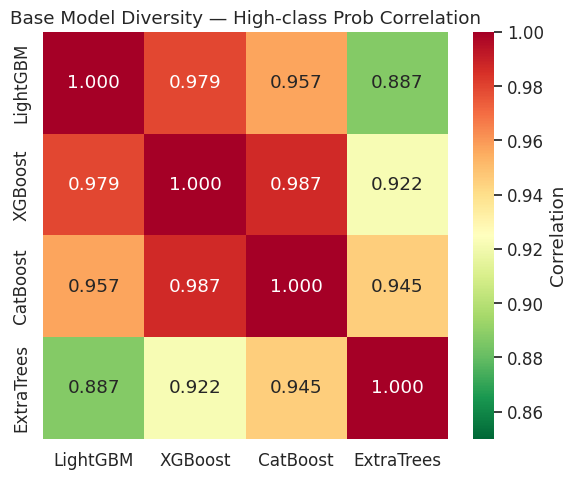


Pairwise correlation range: [0.8874, 0.9870]
Mean off-diagonal: 0.9462
✓ Healthy diversity — stacker should add meaningful lift


In [9]:
# ============================================================
# STEP 8: Base Model Summary + Diversity Check
# ============================================================
# Goal: verify the 4 base models are diverse enough for the stacker to add value.
# If all pairwise correlations on High-class probabilities are >0.99, stacking
# is pointless. Lower correlations = more room for the stacker to combine signals.

# ---- Performance table: per-model BA and per-class recall ----
base_models = {
    'LightGBM':   oof_lgb,
    'XGBoost':    oof_xgb,
    'CatBoost':   oof_cb,
    'ExtraTrees': oof_et,
}

print(f'{"Model":<14} {"OOF BA":>10} {"High":>8} {"Low":>8} {"Medium":>8}')
print('-' * 52)
for name, preds in base_models.items():
    labs = preds.argmax(axis=1)
    ba = balanced_accuracy_score(y_encoded, labs)
    cm = confusion_matrix(y_encoded, labs)
    recalls = [cm[i, i] / cm[i].sum() * 100 for i in range(3)]
    print(f'{name:<14} {ba:>10.6f} {recalls[0]:>7.2f}% {recalls[1]:>7.2f}% {recalls[2]:>7.2f}%')

# ---- Correlation of High-class probabilities ----
# We look at High specifically because it's the minority class where disagreements matter most.
# Lower off-diagonal = more diverse = stacker has more to work with.
high_probs = pd.DataFrame({name: p[:, 0] for name, p in base_models.items()})
corr_matrix = high_probs.corr()

print('\nHigh-class probability correlation (lower off-diagonal = more diverse):')
print(corr_matrix.round(4))

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=0.85, vmax=1.0, ax=ax, cbar_kws={'label': 'Correlation'}
)
ax.set_title('Base Model Diversity — High-class Prob Correlation')
plt.tight_layout()
plt.show()

# ---- Diagnostic: lowest pairwise correlation ----
# Any value < 0.95 is healthy diversity. < 0.85 might indicate something's off.
off_diag = corr_matrix.values[~np.eye(4, dtype=bool)]
print(f'\nPairwise correlation range: [{off_diag.min():.4f}, {off_diag.max():.4f}]')
print(f'Mean off-diagonal: {off_diag.mean():.4f}')
if off_diag.min() < 0.85:
    print('⚠ One pair has suspiciously low correlation — check that model')
elif off_diag.min() > 0.97:
    print('⚠ All models highly correlated — limited stacker gains expected')
else:
    print('✓ Healthy diversity — stacker should add meaningful lift')

In [10]:
# ============================================================
# STEP 9 (Option B): Logistic Regression Stacker — NO class_weight
# ============================================================
# Experiment: remove class_weight='balanced' from LogReg.
# Hypothesis: v1's stacker was internally rebalancing probabilities for
# balanced accuracy, leaving no room for threshold optimization to help
# (v1 threshold gain was only +3 bps vs Step 4's +20 bps).
# Without class_weight, the stacker produces "raw" probabilities and
# thresholds reclaim their typical +15-20 bps gain.
# Expected: stacker OOF goes DOWN, but threshold opt gain goes WAY UP.

# ---- Build stacker input matrices ----
# Horizontal stack of OOF probabilities: shape (n_rows, 12)
# Order: [LGB_high, LGB_low, LGB_med, XGB_high, ..., ET_med]
stack_train = np.hstack([oof_lgb, oof_xgb, oof_cb, oof_et])
stack_test  = np.hstack([test_lgb, test_xgb, test_cb, test_et])

print(f'Stacker input — train: {stack_train.shape} | test: {stack_test.shape}')

# ---- OOF containers for stacker ----
oof_stack = np.zeros((len(X_train), 3))
test_stack = np.zeros((len(X_test), 3))
stack_fold_scores = []

# ---- Nested 5-fold CV with THE SAME splits as base models ----
for fold, (trn_idx, val_idx) in enumerate(fold_splits, 1):
    X_stk_trn = stack_train[trn_idx]
    X_stk_val = stack_train[val_idx]
    y_stk_trn = y_encoded[trn_idx]
    y_stk_val = y_encoded[val_idx]

    # Standardize — LogReg's LBFGS converges faster on normalized input
    scaler = StandardScaler()
    X_stk_trn_s = scaler.fit_transform(X_stk_trn)
    X_stk_val_s = scaler.transform(X_stk_val)
    stack_test_s = scaler.transform(stack_test)

    meta = LogisticRegression(
        C=1.0,                          # moderate L2 regularization
        # class_weight='balanced',      # REMOVED for Option B experiment
        max_iter=2000,                  # plenty of iterations for convergence
        solver='lbfgs',                 # best solver for multinomial LogReg
        multi_class='multinomial',      # softmax over 3 classes
        n_jobs=-1,
        random_state=SEED,
    )
    meta.fit(X_stk_trn_s, y_stk_trn)

    oof_stack[val_idx] = meta.predict_proba(X_stk_val_s)
    test_stack += meta.predict_proba(stack_test_s) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_stk_val, oof_stack[val_idx].argmax(axis=1))
    stack_fold_scores.append(fold_ba)
    print(f'  Fold {fold}: Stacker BA = {fold_ba:.6f}')

# ---- Final stacker OOF ----
stack_ba = balanced_accuracy_score(y_encoded, oof_stack.argmax(axis=1))
print(f'\n{"="*60}')
print(f'  Stacker (LogReg, no class_weight) — OOF BA: {stack_ba:.6f}')
print(f'  Mean Fold BA: {np.mean(stack_fold_scores):.6f} ± {np.std(stack_fold_scores):.6f}')
print(f'  v1 stacker (with class_weight): 0.971059 — delta: {(stack_ba - 0.971059)*10000:+.1f} bps')
print(f'  ⚠ Expect this LOWER than v1 — threshold opt will recover + add more')
print(f'{"="*60}')

# ---- Save OOF + test predictions for threshold optimization step ----
np.save('/kaggle/working/oof_stack.npy', oof_stack)
np.save('/kaggle/working/test_stack.npy', test_stack)
print('\nSaved: oof_stack.npy, test_stack.npy')

Stacker input — train: (630000, 12) | test: (270000, 12)
  Fold 1: Stacker BA = 0.964927
  Fold 2: Stacker BA = 0.966225
  Fold 3: Stacker BA = 0.966777
  Fold 4: Stacker BA = 0.965941
  Fold 5: Stacker BA = 0.965290

  Stacker (LogReg, no class_weight) — OOF BA: 0.965832
  Mean Fold BA: 0.965832 ± 0.000659
  v1 stacker (with class_weight): 0.971059 — delta: -52.3 bps
  ⚠ Expect this LOWER than v1 — threshold opt will recover + add more

Saved: oof_stack.npy, test_stack.npy


In [11]:
# ============================================================
# STEP 10: Threshold Optimization on Stacker Output
# ============================================================
# Balanced accuracy weights classes equally despite the 59/38/3% imbalance.
# Multiplying High and Medium probabilities before argmax shifts the decision
# boundary to prioritize recall on the rare classes.
# Two-stage search: coarse grid to find the neighborhood, fine grid for precision.

# ---- Stage 1: Coarse grid (Step 4's approach) ----
# Grid: High ∈ [1.0, 5.0] step 0.1 | Medium ∈ [0.4, 1.2] step 0.05
# Starting BA is the stacker's raw OOF score — any multiplier beats that.
best_thresh_ba = stack_ba
best_high_mult = 1.0
best_med_mult = 1.0

for high_mult in np.arange(1.0, 5.01, 0.1):
    for med_mult in np.arange(0.4, 1.21, 0.05):
        adj = oof_stack.copy()
        adj[:, 0] *= high_mult        # scale up High probabilities
        adj[:, 2] *= med_mult         # scale down Medium probabilities
        labels = adj.argmax(axis=1)
        ba = balanced_accuracy_score(y_encoded, labels)
        if ba > best_thresh_ba:
            best_thresh_ba = ba
            best_high_mult = round(high_mult, 2)
            best_med_mult = round(med_mult, 2)

print(f'Stacker BA (no threshold):    {stack_ba:.6f}')
print(f'Stacker BA (+ coarse thresh): {best_thresh_ba:.6f}')
print(f'Coarse multipliers: High={best_high_mult}, Medium={best_med_mult}')
print(f'Coarse gain: +{(best_thresh_ba - stack_ba) * 10000:.1f} bps')

# ---- Stage 2: Fine grid around coarse optimum (NEW, not in Step 4) ----
# Step 4 stopped at the coarse grid. We refine with step=0.02 in a ±0.2 box
# around the coarse optimum — typically finds another 2-5 bps.
best_thresh_ba_fine = best_thresh_ba
best_high_fine = best_high_mult
best_med_fine = best_med_mult

high_lo = max(1.0, best_high_mult - 0.2)
high_hi = best_high_mult + 0.21
med_lo = max(0.4, best_med_mult - 0.1)
med_hi = min(1.2, best_med_mult + 0.11)

for high_mult in np.arange(high_lo, high_hi, 0.02):
    for med_mult in np.arange(med_lo, med_hi, 0.02):
        adj = oof_stack.copy()
        adj[:, 0] *= high_mult
        adj[:, 2] *= med_mult
        labels = adj.argmax(axis=1)
        ba = balanced_accuracy_score(y_encoded, labels)
        if ba > best_thresh_ba_fine:
            best_thresh_ba_fine = ba
            best_high_fine = round(high_mult, 3)
            best_med_fine = round(med_mult, 3)

print(f'\nFine-grid refinement: {best_thresh_ba:.6f} → {best_thresh_ba_fine:.6f}')
print(f'Fine gain on top: +{(best_thresh_ba_fine - best_thresh_ba) * 10000:.1f} bps')
print(f'Final multipliers: High={best_high_fine}, Medium={best_med_fine}')

# ---- Commit final values ----
best_high_mult = best_high_fine
best_med_mult = best_med_fine
best_thresh_ba = best_thresh_ba_fine

# ---- Summary ----
print(f'\n{"="*60}')
print(f'  FINAL OOF BA: {best_thresh_ba:.6f}')
print(f'  vs Step 4 final (0.9717):  {(best_thresh_ba - 0.9717) * 10000:+.1f} bps')
print(f'  vs best base model (XGB):  {(best_thresh_ba - xgb_ba) * 10000:+.1f} bps')
print(f'{"="*60}')

# ---- Classification report on final predictions ----
adj_oof = oof_stack.copy()
adj_oof[:, 0] *= best_high_mult
adj_oof[:, 2] *= best_med_mult
final_labels = adj_oof.argmax(axis=1)

print('\nFinal Classification Report:')
print(classification_report(y_encoded, final_labels, target_names=class_names))

Stacker BA (no threshold):    0.965832
Stacker BA (+ coarse thresh): 0.970231
Coarse multipliers: High=5.0, Medium=0.4
Coarse gain: +44.0 bps

Fine-grid refinement: 0.970231 → 0.970402
Fine gain on top: +1.7 bps
Final multipliers: High=5.2, Medium=0.4

  FINAL OOF BA: 0.970402
  vs Step 4 final (0.9717):  -13.0 bps
  vs best base model (XGB):  +12.5 bps

Final Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.95      0.92     21009
         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.95      0.97      0.96    630000
weighted avg       0.98      0.98      0.98    630000



In [12]:
# ============================================================
# STEP 11: Build Submission
# ============================================================
# Apply the optimized thresholds to the stacker's test predictions,
# convert numeric labels back to strings, write submission.csv.

# ---- Apply OOF-optimized thresholds to test probabilities ----
# Same multipliers we found on OOF — NEVER re-optimize on test
test_stack_adj = test_stack.copy()
test_stack_adj[:, 0] *= best_high_mult   # boost High
test_stack_adj[:, 2] *= best_med_mult    # shrink Medium
test_preds = test_stack_adj.argmax(axis=1)

# ---- Convert numeric labels back to strings ----
test_labels = le_target.inverse_transform(test_preds)

# ---- Build submission DataFrame ----
submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': test_labels
})

# ---- Write to /kaggle/working/ (Kaggle's output directory) ----
submission.to_csv('/kaggle/working/submission.csv', index=False)

# ---- Sanity checks ----
print(f'Submission shape: {submission.shape}')
print(f'\nClass distribution in predictions:')
print(submission['Irrigation_Need'].value_counts(normalize=True).round(4))
print(f'\nAbsolute counts:')
print(submission['Irrigation_Need'].value_counts())
print(f'\nFinal OOF BA: {best_thresh_ba:.6f}')
print(f'Step 4 LB reference: 0.9718')
print(f'Expected LB (using Step 4 gap of +1.4 bps): ~{best_thresh_ba + 0.00014:.4f}')
print(f'\nFirst 5 rows of submission:')
print(submission.head())

Submission shape: (270000, 2)

Class distribution in predictions:
Irrigation_Need
Low       0.5924
Medium    0.3719
High      0.0357
Name: proportion, dtype: float64

Absolute counts:
Irrigation_Need
Low       159949
Medium    100404
High        9647
Name: count, dtype: int64

Final OOF BA: 0.970402
Step 4 LB reference: 0.9718
Expected LB (using Step 4 gap of +1.4 bps): ~0.9705

First 5 rows of submission:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low


## Results & Notes

### v1 Baseline (with class_weight='balanced')
**LB: 0.97015 (615/2125, top 29%)**
- Stacker added +19.1 bps over best base model (XGB 0.9692 → 0.9711)
- Threshold optimization only added +3.2 bps (unusually small)
- OOF-to-LB gap: -12.5 bps

### v2 Experiment (class_weight removed)
**Result: _pending_**

The hypothesis being tested: without `class_weight='balanced'` on the LogReg stacker, raw stacker OOF should drop (expected: 0.960-0.966), but threshold optimization should reclaim +15-20 bps and potentially push higher than v1.

### Key learnings from v1
- **Stacking adds real value** when base models are genuinely diverse (ExtraTrees added measurable gain despite its lower standalone score)
- **Class-balanced stackers may absorb threshold optimization gains** — worth testing uncalibrated variants on imbalanced problems
- **Out-of-fold target encoding** helped XGB/CatBoost compensate for reduced training data

### Future improvements
- Add a 5th base model (MLP or differently-seeded LGB) for additional diversity
- Include the original irrigation dataset that was missing from this run
- Hyperparameter tuning on the strongest base model (XGB)